# Notebook 04 — Clasificación Multiclase (7 Clases)
## Clasificación de Lesiones Cutáneas Pigmentadas (HAM10000)
**Iteración 3:** ResNet50 con fine-tuning progresivo · 7 categorías diagnósticas

---
### Objetivo
Extender la mejor arquitectura de la Iteración 2 (ResNet50) a las 7 clases del HAM10000,  
con manejo explícito del desbalance severo (nv = 66.9% vs. df = 1.1%).

### Estrategias de mitigación de desbalance implementadas
- **Pesos de clase** en `CrossEntropyLoss` (inversamente proporcional a frecuencia)
- **Data augmentation** clínicamente válido (flips, rotaciones, brillo leve)
- **Fine-tuning progresivo**: Fase 1 → solo capa FC; Fase 2 → descongelar layer4 + FC

### Estructura
1. Ingesta y DataLoaders multiclase (mismo split por lesion_id)
2. Configuración ResNet50 para 7 clases
3. Fase 1: Entrenamiento cabeza (FC) — 8 épocas
4. Fase 2: Fine-tuning progresivo (layer4 + FC) — 5 épocas adicionales
5. Evaluación completa: balanced accuracy, F1-macro, AUC-ROC one-vs-rest
6. Matriz de confusión 7×7 y análisis por clase
7. Análisis de errores: clases más confundidas


In [1]:
# ============================================================
# CELDA 1: INSTALACIONES Y CONFIGURACIÓN
# ============================================================
!pip install -q kaggle scikit-learn matplotlib seaborn pandas Pillow torch torchvision tqdm
import os, json, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
import torchvision.models as models
from glob import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (confusion_matrix, classification_report,
                              balanced_accuracy_score, roc_auc_score,
                              f1_score, roc_curve, auc)
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print(f"Dispositivo: {device}")


Dispositivo: cpu


In [ ]:
# ============================================================
# CELDA 2: INGESTA DE DATOS — INGRESAR CREDENCIALES KAGGLE
# ============================================================
import os, json, zipfile
import glob as glob_module
from getpass import getpass

UNZIP_DIR = '/content/dataset/unzipped'

if not os.path.exists(UNZIP_DIR) or len(os.listdir(UNZIP_DIR)) == 0:
    os.makedirs(UNZIP_DIR, exist_ok=True)

    print("=" * 50)
    print("  CREDENCIALES DE KAGGLE")
    print("  Obtén tu API key en: kaggle.com/settings → API")
    print("=" * 50)
    KAGGLE_USERNAME = input("Ingresa tu usuario de Kaggle: ")
    KAGGLE_KEY      = getpass("Ingresa tu API key de Kaggle: ")

    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

    print("\nDescargando dataset HAM10000 (~2.5 GB, espera unos minutos)...")
    !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 \
        -p /content/dataset -q
    print("Descomprimiendo...")
    with zipfile.ZipFile(
        '/content/dataset/skin-cancer-mnist-ham10000.zip', 'r') as zf:
        zf.extractall(UNZIP_DIR)
    print("✅ Dataset listo")

else:
    print("✅ Dataset ya disponible en", UNZIP_DIR)

# ── Buscar CSV automáticamente ──────────────────────────────
csvs      = glob_module.glob('/content/**/*metadata*.csv', recursive=True)
CSV_PATH  = csvs[0] if csvs else f'{UNZIP_DIR}/HAM10000_metadata.csv'
IMAGE_DIR = UNZIP_DIR
print(f"CSV encontrado: {CSV_PATH}")

⚠️  Kaggle Secrets no disponibles → usando Google Drive...
Mounted at /content/drive
Copiando desde Google Drive (puede tardar unos minutos)...
✅ Dataset cargado desde Google Drive
CSV encontrado: /content/dataset/unzipped/HAM10000_images_part_1/HAM10000_metadata.csv


In [4]:
# ============================================================
# CELDA 3: DATASET MULTICLASE Y SPLIT POR LESION_ID
# ============================================================
CLASES = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
NOMBRES_CLASES = {
    'nv':'Melanocytic nevi', 'mel':'Melanoma', 'bkl':'Benign keratosis',
    'bcc':'Basal cell carcinoma', 'akiec':'Actinic keratoses',
    'vasc':'Vascular lesions', 'df':'Dermatofibroma'
}

class HAM10000_Multi(Dataset):
    """Dataset multiclase (7 categorías) — imágenes RGB 3 canales."""
    def __init__(self, df, transform=None):
        self.df          = df.reset_index(drop=True)
        self.transform   = transform
        self.class_to_idx = {c: i for i, c in enumerate(CLASES)}
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        img   = Image.open(self.df['path'].iloc[idx]).convert('RGB')
        label = self.class_to_idx[self.df['dx'].iloc[idx]]
        if self.transform: img = self.transform(img)
        return img, label

# Metadatos
df_meta = pd.read_csv(CSV_PATH)
todas   = glob(os.path.join(UNZIP_DIR,'**','*.jpg'), recursive=True)
df_meta['path'] = df_meta['image_id'].map(
    {os.path.splitext(os.path.basename(x))[0]: x for x in todas})
df_meta = df_meta.dropna(subset=['path'])

# Split por lesion_id
groups   = df_meta['lesion_id'].values
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
idx_tv, idx_test = next(gss_test.split(np.arange(len(df_meta)), groups=groups))
gss_val  = GroupShuffleSplit(n_splits=1, test_size=0.111, random_state=SEED)
idx_tr_r, idx_val_r = next(gss_val.split(idx_tv, groups=groups[idx_tv]))
df_train = df_meta.iloc[idx_tv[idx_tr_r]]
df_val   = df_meta.iloc[idx_tv[idx_val_r]]
df_test  = df_meta.iloc[idx_test]
print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
transform_val = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

BATCH = 32
train_loader = DataLoader(HAM10000_Multi(df_train, transform_train),
                          batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(HAM10000_Multi(df_val,   transform_val),
                          batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(HAM10000_Multi(df_test,  transform_val),
                          batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

# Pesos de clase
y_train = df_train['dx'].values
pesos_np = compute_class_weight('balanced', classes=np.array(CLASES), y=y_train)
pesos_tensor = torch.tensor(pesos_np, dtype=torch.float).to(device)

print("\n--- Distribución en train y pesos asignados ---")
for c, p in zip(CLASES, pesos_np):
    n = (df_train['dx'] == c).sum()
    print(f"  {c:6s}: {n:4d} imgs | peso = {p:.3f}")


Train: 3988 | Val: 497 | Test: 515

--- Distribución en train y pesos asignados ---
  nv    : 2715 imgs | peso = 0.210
  mel   :  354 imgs | peso = 1.609
  bkl   :  469 imgs | peso = 1.215
  bcc   :  210 imgs | peso = 2.713
  akiec :  144 imgs | peso = 3.956
  vasc  :   52 imgs | peso = 10.956
  df    :   44 imgs | peso = 12.948


### Celda 4 — ResNet50 para 7 clases
Se parte de los pesos preentrenados en ImageNet. En la **Fase 1** solo se entrena la capa FC.  
En la **Fase 2** se descongela el bloque `layer4` del backbone para fine-tuning más profundo.


In [ ]:
# ============================================================
# CELDA 4: CONFIGURAR RESNET50 PARA 7 CLASES
# ============================================================
modelo = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Congelar TODO el backbone inicialmente
for p in modelo.parameters():
    p.requires_grad = False

# Reemplazar FC: 2048 → 7 clases
modelo.fc = nn.Linear(modelo.fc.in_features, 7)
modelo     = modelo.to(device)

trainable = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
total     = sum(p.numel() for p in modelo.parameters())
print(f"Fase 1 — Parámetros entrenables: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)")
print("       → Solo la capa FC (clasificador) está activa")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 89.4MB/s]


Fase 1 — Parámetros entrenables: 14,343 / 23,522,375 (0.1%)
       → Solo la capa FC (clasificador) está activa


In [ ]:
# ============================================================
# CELDA 5: FUNCIÓN DE ENTRENAMIENTO MULTICLASE
# ============================================================
def entrenar_fase(modelo, epochs, lr, nombre_fase):
    criterio    = nn.CrossEntropyLoss(weight=pesos_tensor)
    params      = [p for p in modelo.parameters() if p.requires_grad]
    optimizador = optim.Adam(params, lr=lr)
    hist        = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc']}

    print(f"\n{'='*50}")
    print(f"  {nombre_fase}")
    print(f"  LR={lr} | Épocas={epochs} | Params activos={sum(p.numel() for p in params):,}")
    print(f"{'='*50}")

    for epoch in range(epochs):
        modelo.train()
        tl, tc, tt = 0., 0, 0
        for X, y in tqdm(train_loader, desc=f'Época {epoch+1}/{epochs}', leave=False):
            X, y = X.to(device), y.to(device)
            optimizador.zero_grad()
            out  = modelo(X); loss = criterio(out, y)
            loss.backward(); optimizador.step()
            tl += loss.item()*X.size(0)
            tc += (out.argmax(1)==y).sum().item(); tt += y.size(0)

        modelo.eval(); vl, vc, vt = 0., 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                out  = modelo(X); loss = criterio(out, y)
                vl += loss.item()*X.size(0)
                vc += (out.argmax(1)==y).sum().item(); vt += y.size(0)

        hist['train_loss'].append(tl/tt); hist['val_loss'].append(vl/vt)
        hist['train_acc'].append(tc/tt);  hist['val_acc'].append(vc/vt)
        print(f"  Época {epoch+1:2d} | Train Acc: {tc/tt:.4f} | "
              f"Val Loss: {vl/vt:.4f} | Val Acc: {vc/vt:.4f}")

    return hist


### Celda 6 — Fase 1: Entrenamiento de la cabeza (solo FC)


In [ ]:
# ============================================================
# CELDA 6: FASE 1 — SOLO FC (8 ÉPOCAS)
# ============================================================
hist_fase1 = entrenar_fase(modelo, epochs=8, lr=0.001, nombre_fase='FASE 1 — Solo FC')



  FASE 1 — Solo FC
  LR=0.001 | Épocas=8 | Params activos=14,343


  Época  1 | Train Acc: 0.5021 | Val Loss: 1.3498 | Val Acc: 0.5025


  Época  2 | Train Acc: 0.5733 | Val Loss: 0.9500 | Val Acc: 0.6239


  Época  3 | Train Acc: 0.6072 | Val Loss: 1.2130 | Val Acc: 0.5353


  Época  4 | Train Acc: 0.6289 | Val Loss: 1.1742 | Val Acc: 0.5433


  Época  5 | Train Acc: 0.6166 | Val Loss: 0.9109 | Val Acc: 0.6358


  Época  6 | Train Acc: 0.6240 | Val Loss: 0.8580 | Val Acc: 0.6498


  Época  7 | Train Acc: 0.6388 | Val Loss: 0.8928 | Val Acc: 0.6547


  Época  8 | Train Acc: 0.6410 | Val Loss: 1.1118 | Val Acc: 0.5781


### Celda 7 — Fase 2: Fine-tuning progresivo (layer4 + FC)
Se descongela el último bloque residual (`layer4`) con un learning rate más bajo  
para evitar sobreescribir los pesos preentrenados del backbone.


In [ ]:
# ============================================================
# CELDA 7: FASE 2 — DESCONGELAR LAYER4 + FC (5 ÉPOCAS)
# ============================================================
# Descongelar el último bloque residual del backbone
for p in modelo.layer4.parameters():
    p.requires_grad = True

trainable_f2 = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
total_f2     = sum(p.numel() for p in modelo.parameters())
print(f"Fase 2 — Parámetros entrenables: {trainable_f2:,} / {total_f2:,} "
      f"({trainable_f2/total_f2*100:.1f}%)")
print("         → layer4 + FC activos (LR reducido para no destruir ImageNet weights)")

hist_fase2 = entrenar_fase(modelo, epochs=5, lr=0.0001,
                           nombre_fase='FASE 2 — Fine-tuning layer4 + FC')


Fase 2 — Parámetros entrenables: 14,979,079 / 23,522,375 (63.7%)
         → layer4 + FC activos (LR reducido para no destruir ImageNet weights)

  FASE 2 — Fine-tuning layer4 + FC
  LR=0.0001 | Épocas=5 | Params activos=14,979,079


  Época  1 | Train Acc: 0.6438 | Val Loss: 1.1727 | Val Acc: 0.5701


  Época  2 | Train Acc: 0.7034 | Val Loss: 0.9000 | Val Acc: 0.6637


  Época  3 | Train Acc: 0.7377 | Val Loss: 0.6609 | Val Acc: 0.7353


  Época  4 | Train Acc: 0.7461 | Val Loss: 0.6724 | Val Acc: 0.7413


  Época  5 | Train Acc: 0.7655 | Val Loss: 0.5911 | Val Acc: 0.7522


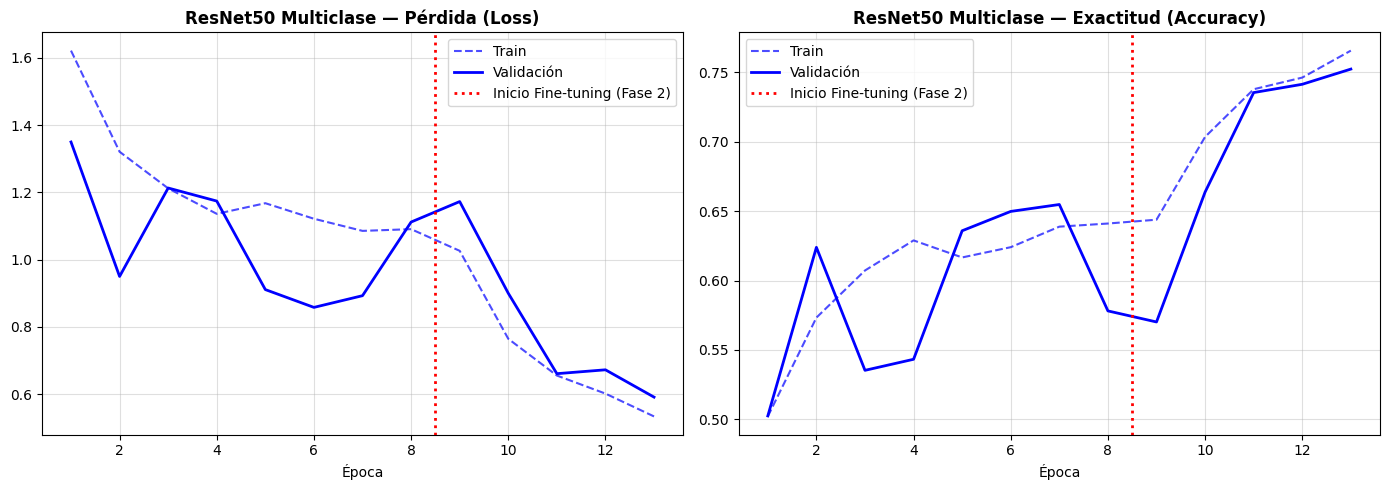

In [ ]:
# ============================================================
# CELDA 8: CURVAS DE APRENDIZAJE (FASE 1 + FASE 2)
# ============================================================
# Concatenar historial
hist_total = {k: hist_fase1[k] + hist_fase2[k]
              for k in ['train_loss','val_loss','train_acc','val_acc']}
epocas     = range(1, len(hist_total['train_loss']) + 1)
fase2_inicio = len(hist_fase1['train_loss'])  # línea divisoria

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (tk, vk), titulo in zip(
    axes,
    [('train_loss','val_loss'), ('train_acc','val_acc')],
    ['Pérdida (Loss)', 'Exactitud (Accuracy)']
):
    ax.plot(epocas, hist_total[tk], 'b--', label='Train', alpha=0.7)
    ax.plot(epocas, hist_total[vk], 'b-',  label='Validación', linewidth=2)
    ax.axvline(x=fase2_inicio + 0.5, color='red', linestyle=':', linewidth=2,
               label='Inicio Fine-tuning (Fase 2)')
    ax.set_title(f'ResNet50 Multiclase — {titulo}', fontweight='bold')
    ax.set_xlabel('Época'); ax.legend(); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('/content/fig_multiclase_curvas.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ============================================================
# CELDA 9: EVALUACIÓN FINAL EN TEST SET
# ============================================================
modelo.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for X, y in test_loader:
        X   = X.to(device)
        out = modelo(X)
        p   = torch.softmax(out, dim=1)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())
        all_probs.extend(p.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)  # shape (N, 7)

acc      = (all_preds == all_labels).mean()
bal_acc  = balanced_accuracy_score(all_labels, all_preds)
f1_macro = f1_score(all_labels, all_preds, average='macro')
auc_macro = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

print("="*55)
print("  EVALUACIÓN FINAL — TEST SET (ResNet50 Multiclase)")
print("="*55)
print(f"  Accuracy           : {acc:.4f}")
print(f"  Balanced Accuracy  : {bal_acc:.4f}  ← métrica principal")
print(f"  F1-Score Macro     : {f1_macro:.4f}")
print(f"  AUC-ROC Macro (OvR): {auc_macro:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=CLASES))


  EVALUACIÓN FINAL — TEST SET (ResNet50 Multiclase)
  Accuracy           : 0.7427
  Balanced Accuracy  : 0.6937  ← métrica principal
  F1-Score Macro     : 0.6024
  AUC-ROC Macro (OvR): 0.9494

              precision    recall  f1-score   support

          nv       0.94      0.79      0.86       676
         mel       0.47      0.54      0.50       122
         bkl       0.53      0.66      0.59       113
         bcc       0.48      0.74      0.58        50
       akiec       0.45      0.75      0.56        32
        vasc       0.69      0.87      0.77        23
          df       0.26      0.50      0.34        10

    accuracy                           0.74      1026
   macro avg       0.55      0.69      0.60      1026
weighted avg       0.79      0.74      0.76      1026



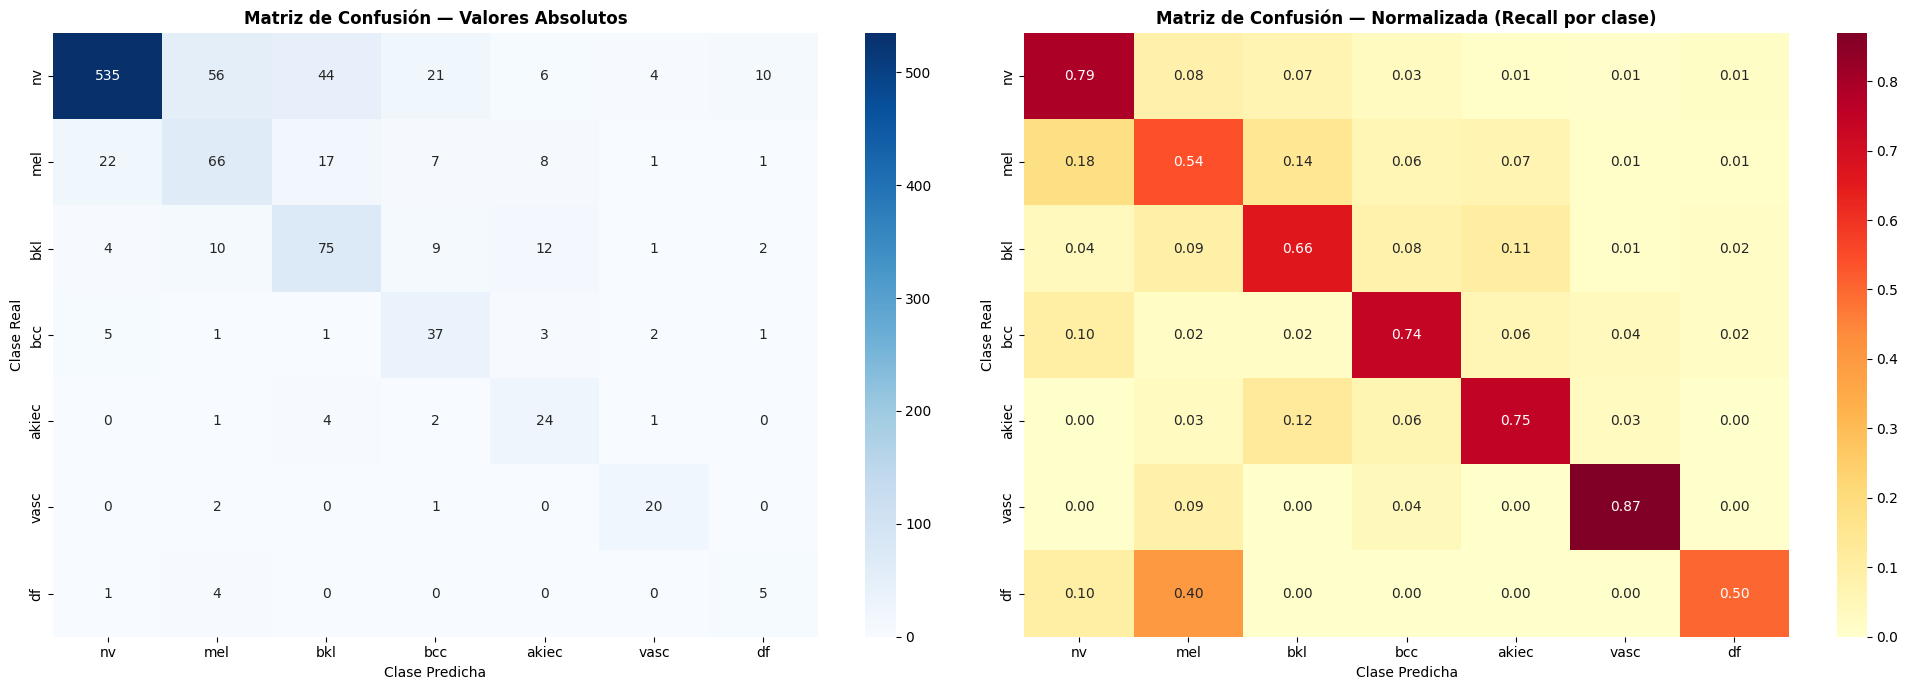


--- ANÁLISIS DE RECALL POR CLASE ---
  nv    : Recall = 0.791 | Error principal → confundido con 'mel'
  mel   : Recall = 0.541 | Error principal → confundido con 'nv'
  bkl   : Recall = 0.664 | Error principal → confundido con 'akiec'
  bcc   : Recall = 0.740 | Error principal → confundido con 'nv'
  akiec : Recall = 0.750 | Error principal → confundido con 'bkl'
  vasc  : Recall = 0.870 | Error principal → confundido con 'mel'
  df    : Recall = 0.500 | Error principal → confundido con 'mel'


In [ ]:
# ============================================================
# CELDA 10: MATRIZ DE CONFUSIÓN 7×7 Y ANÁLISIS
# ============================================================
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASES, yticklabels=CLASES)
axes[0].set_title('Matriz de Confusión — Valores Absolutos', fontweight='bold')
axes[0].set_ylabel('Clase Real'); axes[0].set_xlabel('Clase Predicha')

# Normalizada por fila (recall por clase)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            xticklabels=CLASES, yticklabels=CLASES)
axes[1].set_title('Matriz de Confusión — Normalizada (Recall por clase)', fontweight='bold')
axes[1].set_ylabel('Clase Real'); axes[1].set_xlabel('Clase Predicha')

plt.tight_layout()
plt.savefig('/content/fig_multiclase_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Análisis de errores ──
print("\n--- ANÁLISIS DE RECALL POR CLASE ---")
for i, clase in enumerate(CLASES):
    recall = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    error_principal = CLASES[np.argmax([cm[i,j] if j!=i else 0 for j in range(7)])]
    print(f"  {clase:6s}: Recall = {recall:.3f} | "
          f"Error principal → confundido con '{error_principal}'")


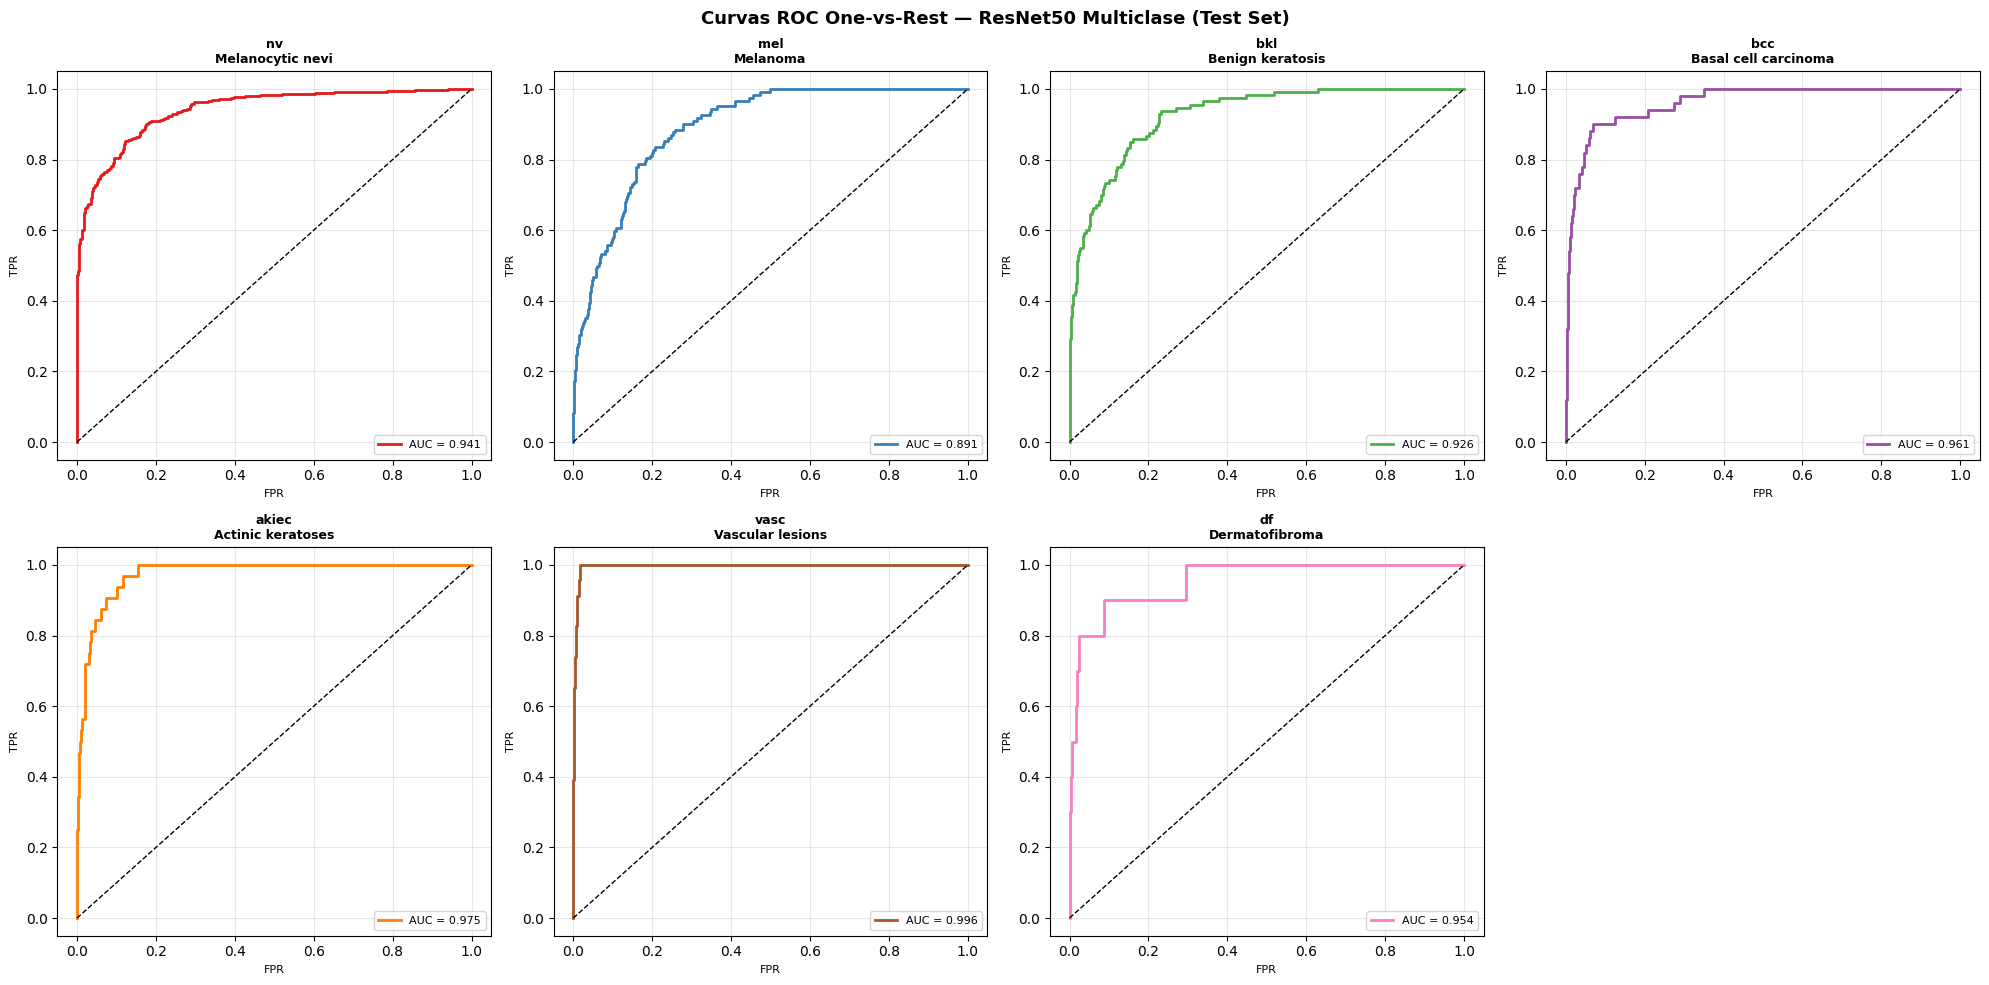


✅ Notebook 04 completado.
   Figuras guardadas en /content/
   Balanced Accuracy final: 0.6937
   AUC-ROC Macro (OvR)    : 0.9494


In [ ]:
# ============================================================
# CELDA 11: CURVAS ROC ONE-VS-REST POR CLASE
# ============================================================
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(all_labels, classes=list(range(7)))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

colores = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628','#f781bf']

for i, (clase, color) in enumerate(zip(CLASES, colores)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_i = auc(fpr, tpr)
    axes[i].plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc_i:.3f}')
    axes[i].plot([0,1],[0,1],'k--', lw=1)
    axes[i].set_title(f'{clase}\n{NOMBRES_CLASES[clase]}', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('FPR', fontsize=8); axes[i].set_ylabel('TPR', fontsize=8)
    axes[i].legend(loc='lower right', fontsize=8); axes[i].grid(True, alpha=0.3)

axes[7].axis('off')  # celda vacía

plt.suptitle('Curvas ROC One-vs-Rest — ResNet50 Multiclase (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig_multiclase_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Notebook 04 completado.")
print("   Figuras guardadas en /content/")
print(f"   Balanced Accuracy final: {bal_acc:.4f}")
print(f"   AUC-ROC Macro (OvR)    : {auc_macro:.4f}")
